<h1 style="text-align: center;">Assessment 1 - Image Segmentation Implementation</h1>
<h2 style="text-align: center;">Computer Vision and Image Analysis</h2> 
<h3 style="text-align: center;">By Ruhan Shafi | u3284342</h3>

---

## Table of Content

* Preliminaries 
    * [Importing Librarires](#importing-libraries-and-geneating-random-seed)
    * [Importing Images & Annotations](#importing-images--annotations)
    * [Verifying that Image and Annonations were imported in correctly](#verifying-that-image-and-annonations-were-imported-in-correctly)
* [Task 1 – Edge-Based Segmentation ](#task-1---edge-based-segmentation)
* [Task 2 – Region-Based Segmentation](#task-2---region-based-segmentation)
* [Task 3 – Clustering-Based Segmentation](#task-3---clustering-based-segmentation)

### Importing Libraries and Geneating Random Seed

In [1]:
import os
import glob
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.13.0


### Importing Images & Annotations

This cell of code is responsible for loading in 

In [2]:
DATASET_DIR = "oxford-iiit-pet-subset"
IMAGE_DIR = os.path.join(DATASET_DIR, "image")
ANNOTATION_DIR = os.path.join(DATASET_DIR, "annotation")

def load_dataset(limit=None):
    images = []
    masks = []
    filenames = []

    image_files = sorted(os.listdir(IMAGE_DIR))

    if limit:
        image_files = image_files[:limit]

    for img_name in image_files:
        name, _ = os.path.splitext(img_name)

        img_path = os.path.join(IMAGE_DIR, img_name)
        mask_path = os.path.join(ANNOTATION_DIR, name + ".png")  # force .png

        if not os.path.exists(mask_path):
            continue

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask
        mask = cv2.imread(mask_path, 0)
        mask = (mask == 1).astype(np.uint8)

        images.append(image)
        masks.append(mask)
        filenames.append(name)

    return images, masks, filenames


images, masks, filenames = load_dataset()
print(f"Loaded {len(images)} image-mask pairs")

Loaded 96 image-mask pairs


### Verifying that Image and Annonations were imported in correctly.

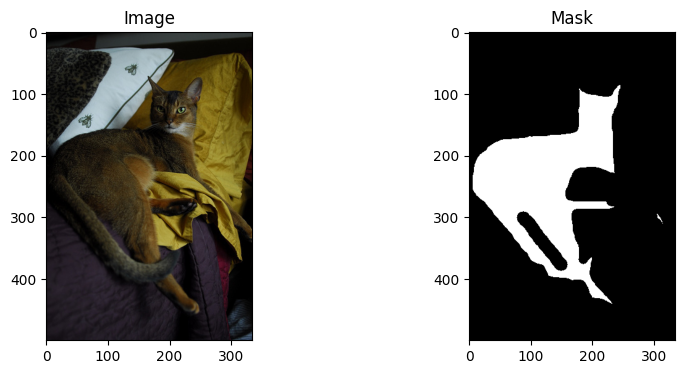

In [3]:
idx = 5 # First sample
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(images[idx])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(masks[idx], cmap='gray')
plt.title("Mask")

plt.show()

# Task 1 - Edge-Based Segmentation

In [4]:
def compute_metrics(pred, gt):
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()

    iou = tp / (tp + fp + fn + 1e-6)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-6)

    return iou, dice, tp, fp, fn

## Prepocessing - 

In [5]:
def edge_segmentation(image, low=50, high=150, blur_k=5):
    # Preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (blur_k, blur_k), 1.0)

    # Canny edge detection
    edges = cv2.Canny(blurred, low, high)

    # Post-processing: close gaps
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Fill contours
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, contours, -1, 255, thickness=cv2.FILLED)

    return (mask > 0).astype(np.uint8)

In [6]:
def edge_refined(image, low=50, high=150, blur_k=5):
    mask = edge_segmentation(image, low, high, blur_k)

    kernel = np.ones((5,5), np.uint8)

    # Remove noise
    refined = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)

    return refined

In [7]:
def tune_parameters(images, masks):
    param_grid = {
        "blur_k": [3, 5, 7],
        "low": [30, 50, 70],
        "high": [100, 150, 200]
    }

    best_score = 0
    best_params = None

    for blur_k in param_grid["blur_k"]:
        for low in param_grid["low"]:
            for high in param_grid["high"]:

                ious = []

                for img, gt in zip(images, masks):
                    pred = edge_segmentation(img, low, high, blur_k)
                    iou, _, _, _, _ = compute_metrics(pred, gt)
                    ious.append(iou)

                avg_iou = np.mean(ious)

                print(f"blur={blur_k}, low={low}, high={high} → IoU={avg_iou:.3f}")

                if avg_iou > best_score:
                    best_score = avg_iou
                    best_params = (low, high, blur_k)

    return best_params, best_score


# Use small subset for validation
best_params, best_score = tune_parameters(images[:20], masks[:20])

print("Best Params (low, high, blur_k):", best_params)
print("Best IoU:", best_score)

blur=3, low=30, high=100 → IoU=0.475
blur=3, low=30, high=150 → IoU=0.408
blur=3, low=30, high=200 → IoU=0.274
blur=3, low=50, high=100 → IoU=0.396
blur=3, low=50, high=150 → IoU=0.261
blur=3, low=50, high=200 → IoU=0.213
blur=3, low=70, high=100 → IoU=0.268
blur=3, low=70, high=150 → IoU=0.196
blur=3, low=70, high=200 → IoU=0.158
blur=5, low=30, high=100 → IoU=0.396
blur=5, low=30, high=150 → IoU=0.251
blur=5, low=30, high=200 → IoU=0.184
blur=5, low=50, high=100 → IoU=0.277
blur=5, low=50, high=150 → IoU=0.195
blur=5, low=50, high=200 → IoU=0.165
blur=5, low=70, high=100 → IoU=0.190
blur=5, low=70, high=150 → IoU=0.137
blur=5, low=70, high=200 → IoU=0.115
blur=7, low=30, high=100 → IoU=0.392
blur=7, low=30, high=150 → IoU=0.246
blur=7, low=30, high=200 → IoU=0.177
blur=7, low=50, high=100 → IoU=0.267
blur=7, low=50, high=150 → IoU=0.189
blur=7, low=50, high=200 → IoU=0.160
blur=7, low=70, high=100 → IoU=0.185
blur=7, low=70, high=150 → IoU=0.133
blur=7, low=70, high=200 → IoU=0.110
B

In [8]:
def evaluate_global(images, masks, params, refined=False):
    tp_total, fp_total, fn_total = 0, 0, 0

    for img, gt in zip(images, masks):

        if refined:
            pred = edge_refined(img, *params)
        else:
            pred = edge_segmentation(img, *params)

        _, _, tp, fp, fn = compute_metrics(pred, gt)

        tp_total += tp
        fp_total += fp
        fn_total += fn

    iou = tp_total / (tp_total + fp_total + fn_total)
    dice = (2 * tp_total) / (2 * tp_total + fp_total + fn_total)

    return iou, dice


iou, dice = evaluate_global(images, masks, best_params)
print("Canny IoU:", iou)
print("Canny Dice:", dice)

# Extension
iou_ref, dice_ref = evaluate_global(images, masks, best_params, refined=True)
print("Refined IoU:", iou_ref)
print("Refined Dice:", dice_ref)

Canny IoU: 0.33579065029301486
Canny Dice: 0.5027593960466139
Refined IoU: 0.33853622392545857
Refined Dice: 0.5058305003246759


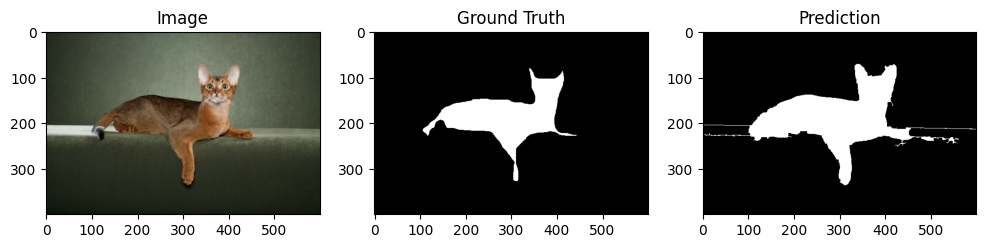

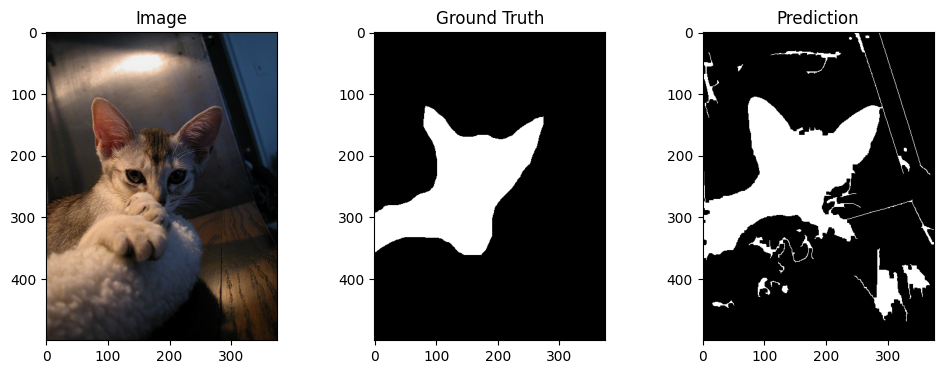

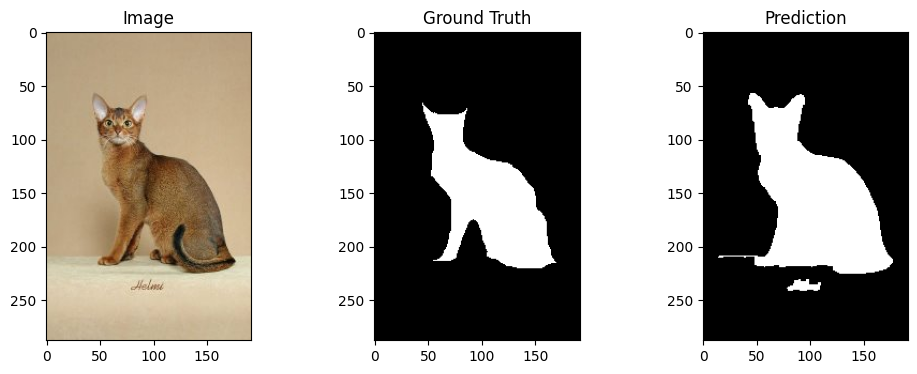

In [9]:
def show_results(image, gt, pred):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction")

    plt.show()


# Show a few examples
for i in [0, 1, 2]:
    pred = edge_segmentation(images[i], *best_params)
    show_results(images[i], masks[i], pred)

# Task 2 - Region-Based Segmentation

In [10]:
import cv2
import numpy as np

def watershed_segmentation(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Preprocessing
    blurred = cv2.GaussianBlur(gray, (5,5), 0)

    # Otsu threshold
    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Noise removal
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Distance transform
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # Foreground extraction (tuned threshold)
    _, sure_fg = cv2.threshold(dist, 0.6 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # Unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Markers
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Watershed
    markers = cv2.watershed(image, markers)

    mask = (markers > 1).astype(np.uint8)

    # Post-processing refinement
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))

    return mask

In [11]:
def tune_watershed(images, masks):
    best_score = 0
    best_thresh = None

    for t in [0.4, 0.5, 0.6, 0.7]:
        ious = []

        for img, gt in zip(images, masks):
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            blurred = cv2.GaussianBlur(gray, (5,5), 0)

            _, thresh = cv2.threshold(
                blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )

            kernel = np.ones((3,3), np.uint8)
            opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

            dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
            _, fg = cv2.threshold(dist, t * dist.max(), 255, 0)

            fg = np.uint8(fg)
            _, markers = cv2.connectedComponents(fg)

            pred = (markers > 0).astype(np.uint8)

            iou, _, _, _, _ = compute_metrics(pred, gt)
            ious.append(iou)

        avg = np.mean(ious)
        print(f"Threshold {t} → IoU {avg:.3f}")

        if avg > best_score:
            best_score = avg
            best_thresh = t

    return best_thresh, best_score

In [12]:
def evaluate_watershed(images, masks):
    tp_total, fp_total, fn_total = 0, 0, 0

    for img, gt in zip(images, masks):
        pred = watershed_segmentation(img)

        _, _, tp, fp, fn = compute_metrics(pred, gt)

        tp_total += tp
        fp_total += fp
        fn_total += fn

    iou = tp_total / (tp_total + fp_total + fn_total)
    dice = (2 * tp_total) / (2 * tp_total + fp_total + fn_total)

    return iou, dice


iou_ws, dice_ws = evaluate_watershed(images, masks)
print("Watershed IoU:", iou_ws)
print("Watershed Dice:", dice_ws)

Watershed IoU: 0.06855543386309333
Watershed Dice: 0.12831423001659054


# Task 3 - Clustering-Based Segmentation

In [13]:
from sklearn.cluster import KMeans

def kmeans_rgb(image, k=2):
    h, w, _ = image.shape

    pixels = image.reshape(-1, 3).astype(np.float32) / 255.0

    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(pixels)

    return labels.reshape(h, w)

In [14]:
def kmeans_rgb_xy(image, k=2):
    h, w, _ = image.shape

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    features = np.concatenate([
        hsv.reshape(-1, 3),
        (X.reshape(-1,1) / w),
        (Y.reshape(-1,1) / h)
    ], axis=1)

    features = features.astype(np.float32)
    features[:, :3] /= 255.0

    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(features)

    return labels.reshape(h, w)

In [15]:
def cluster_to_mask(labels):
    unique, counts = np.unique(labels, return_counts=True)

    bg = unique[np.argmax(counts)]
    mask = (labels != bg).astype(np.uint8)

    # Post-processing
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

In [16]:
def evaluate_kmeans(images, masks, method="rgb"):
    tp_total, fp_total, fn_total = 0, 0, 0

    for img, gt in zip(images, masks):

        if method == "rgb":
            labels = kmeans_rgb(img)
        else:
            labels = kmeans_rgb_xy(img)

        pred = cluster_to_mask(labels)

        _, _, tp, fp, fn = compute_metrics(pred, gt)

        tp_total += tp
        fp_total += fp
        fn_total += fn

    iou = tp_total / (tp_total + fp_total + fn_total)
    dice = (2 * tp_total) / (2 * tp_total + fp_total + fn_total)

    return iou, dice


iou_rgb, dice_rgb = evaluate_kmeans(images, masks, "rgb")
iou_xy, dice_xy = evaluate_kmeans(images, masks, "rgbxy")

print("KMeans RGB IoU:", iou_rgb, "Dice:", dice_rgb)
print("KMeans RGB+XY IoU:", iou_xy, "Dice:", dice_xy)

KMeans RGB IoU: 0.2589235145086017 Dice: 0.41134113633530445
KMeans RGB+XY IoU: 0.20118376559999487 Dice: 0.33497583194442027


In [17]:
def kmeans_refined(image):
    labels = kmeans_rgb_xy(image)
    mask = cluster_to_mask(labels)

    # Additional refinement
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

In [18]:
def evaluate_refined(images, masks):
    tp_total, fp_total, fn_total = 0, 0, 0

    for img, gt in zip(images, masks):
        pred = kmeans_refined(img)

        _, _, tp, fp, fn = compute_metrics(pred, gt)

        tp_total += tp
        fp_total += fp
        fn_total += fn

    iou = tp_total / (tp_total + fp_total + fn_total)
    dice = (2 * tp_total) / (2 * tp_total + fp_total + fn_total)

    return iou, dice


iou_ref, dice_ref = evaluate_refined(images, masks)

print("Refined KMeans IoU:", iou_ref)
print("Refined KMeans Dice:", dice_ref)

Refined KMeans IoU: 0.19988257478491556
Refined KMeans Dice: 0.33317022679614366


In [19]:
import matplotlib.pyplot as plt

def show_all_methods(image, gt):
    ws = watershed_segmentation(image)

    labels_rgb = kmeans_rgb(image)
    km_rgb = cluster_to_mask(labels_rgb)

    labels_xy = kmeans_rgb_xy(image)
    km_xy = cluster_to_mask(labels_xy)

    plt.figure(figsize=(15,6))

    plt.subplot(1,5,1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1,5,2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1,5,3)
    plt.imshow(ws, cmap='gray')
    plt.title("Watershed")
    plt.axis('off')

    plt.subplot(1,5,4)
    plt.imshow(km_rgb, cmap='gray')
    plt.title("KMeans RGB")
    plt.axis('off')

    plt.subplot(1,5,5)
    plt.imshow(km_xy, cmap='gray')
    plt.title("KMeans RGB+XY")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

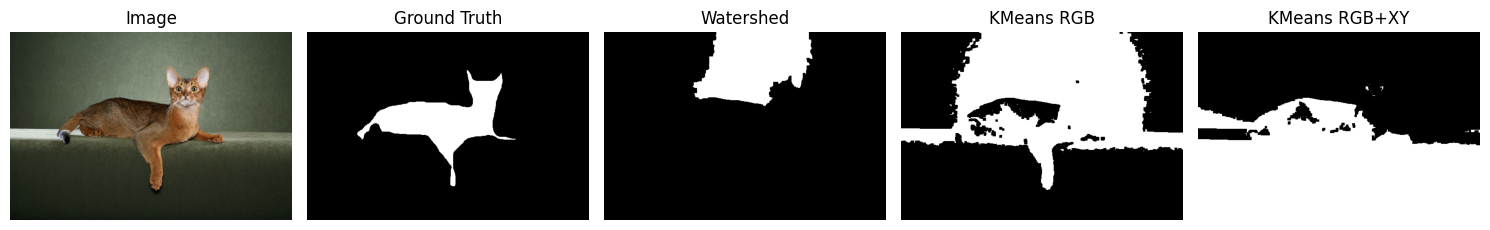

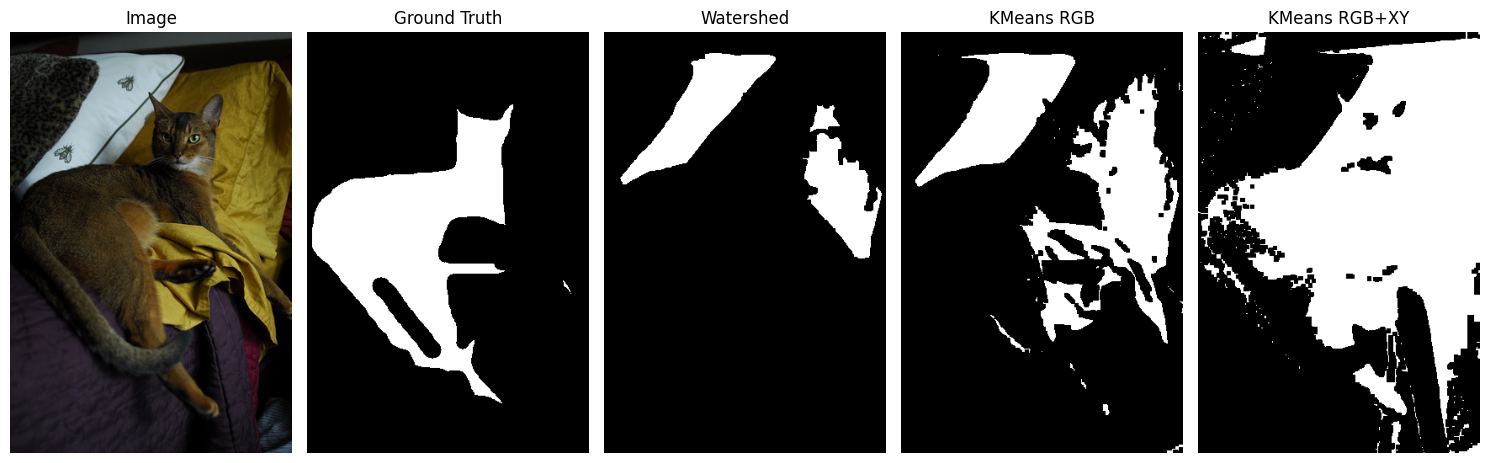

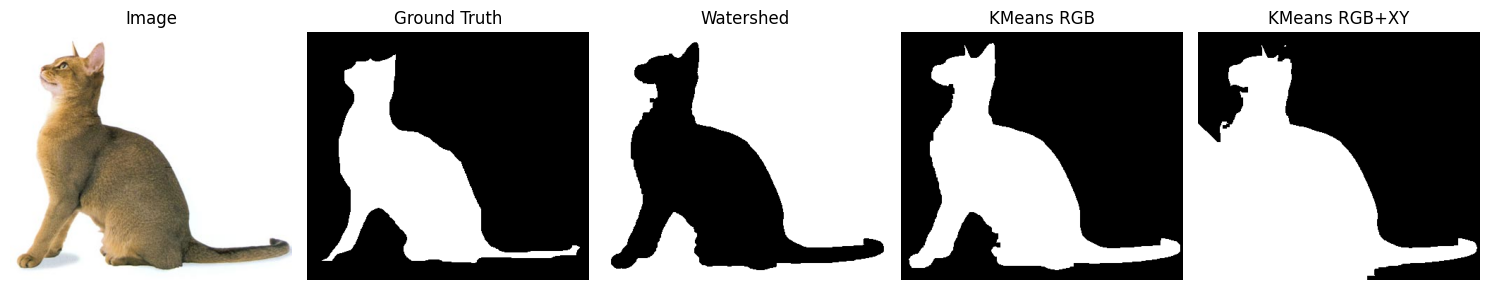

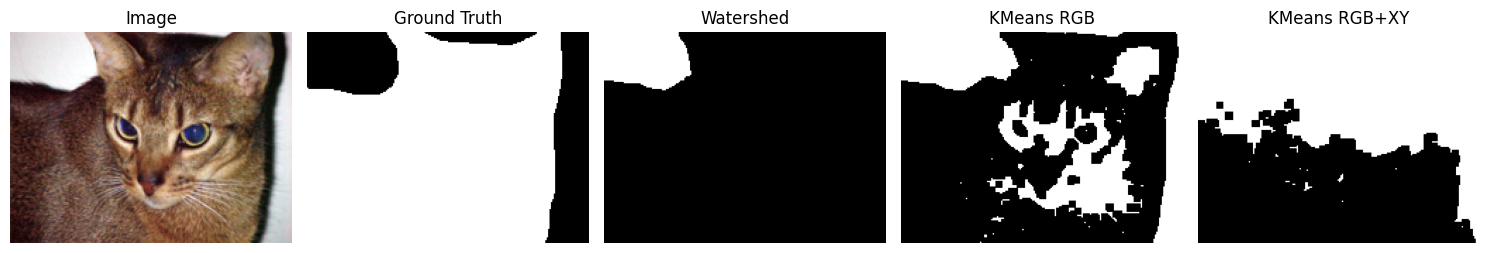

In [20]:
# Pick representative indices manually
indices = [0, 5, 10, 15]

for i in indices:
    show_all_methods(images[i], masks[i])